In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, joblib, shap, os
import matplotlib.pyplot as plt

bundle = joblib.load("../models/scamshield.joblib")
model, FEATURES, T = bundle["model"], bundle["features"], bundle["threshold"]

te = pd.read_parquet("../data/processed/test_scored.parquet")
print(te.shape, "| threshold:", T)

(416297, 22) | threshold: 0.01


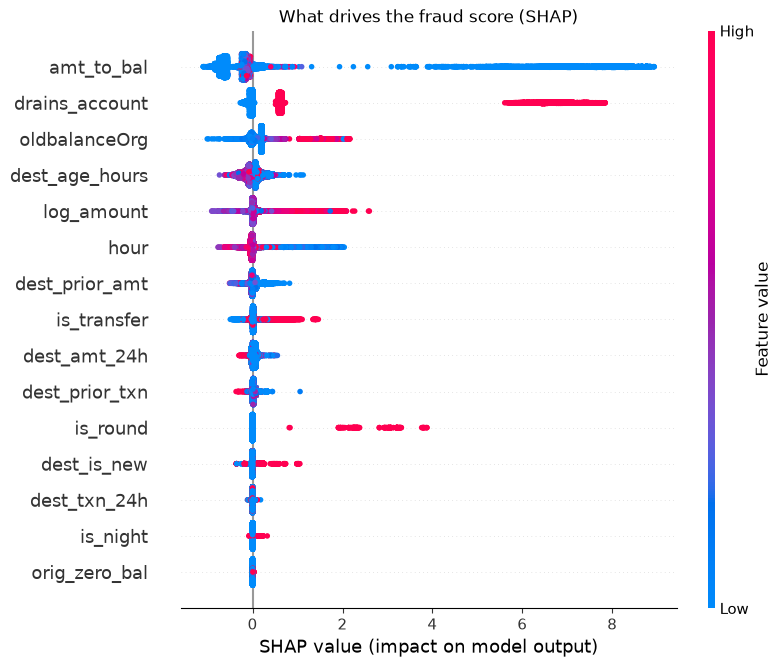

In [2]:
explainer = shap.TreeExplainer(model)

sample = pd.concat([te[te["isFraud"] == 1],
                    te[te["isFraud"] == 0].sample(16_000, random_state=0)])[FEATURES]
sv = explainer(sample)
if sv.values.ndim == 3:      # some shap versions return both classes
    sv = sv[:, :, 1]

shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("What drives the fraud score (SHAP)")
plt.savefig("../reports/figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

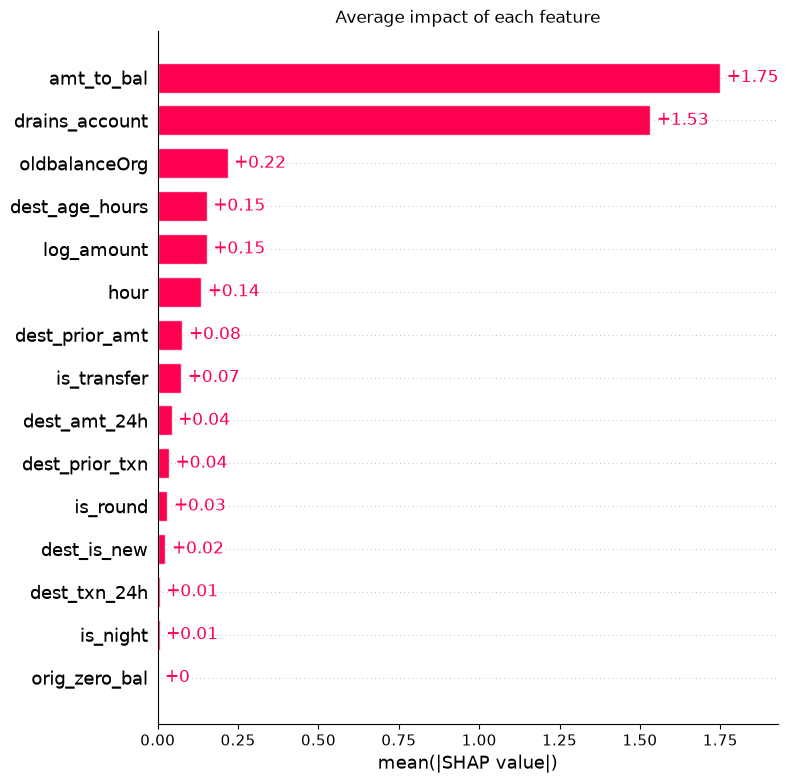

In [3]:
shap.plots.bar(sv, max_display=15, show=False)
plt.title("Average impact of each feature")
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
importance = (pd.Series(np.abs(sv.values).mean(axis=0), index=FEATURES)
                .sort_values(ascending=False).round(3))
importance

amt_to_bal        1.749
drains_account    1.532
oldbalanceOrg     0.217
dest_age_hours    0.153
log_amount        0.152
hour              0.135
dest_prior_amt    0.077
is_transfer       0.073
dest_amt_24h      0.043
dest_prior_txn    0.035
is_round          0.030
dest_is_new       0.024
dest_txn_24h      0.006
is_night          0.006
orig_zero_bal     0.002
dtype: float64

In [5]:
NICE = {
    "is_transfer": "Payment is a transfer",
    "log_amount": "Payment size",
    "oldbalanceOrg": "Sender's balance before payment",
    "amt_to_bal": "Payment as a share of balance",
    "orig_zero_bal": "Sender balance is zero",
    "drains_account": "Payment empties the account",
    "is_round": "Round-number amount",
    "hour": "Time of day",
    "is_night": "Night-time payment (0–5am)",
    "dest_prior_txn": "Receiver's number of past payments",
    "dest_prior_amt": "Receiver's past amount received",
    "dest_age_hours": "How long the receiver has existed",
    "dest_is_new": "Receiver is brand new",
    "dest_txn_24h": "Receiver's payments in last 24h",
    "dest_amt_24h": "Receiver's amount received in last 24h",
}

alerts = te[te["score"] >= T].copy()
sva = explainer(alerts[FEATURES])
vals = sva.values if sva.values.ndim == 2 else sva.values[:, :, 1]
top = np.argsort(-vals, axis=1)[:, :3]
for k in range(3):
    alerts[f"reason_{k+1}"] = [NICE[FEATURES[i]] for i in top[:, k]]

print("Most common main reason for an alert:")
print(alerts["reason_1"].value_counts().head(5))
alerts[["type", "amount", "score", "isFraud", "reason_1", "reason_2", "reason_3"]].head(10)

Most common main reason for an alert:
reason_1
Payment as a share of balance    2561
Payment empties the account      1704
Round-number amount                 3
Name: count, dtype: int64


,type,amount,score,isFraud,reason_1,reason_2,reason_3
1159,CASH_OUT,104350.15,0.193548,0,Payment empties the account,Payment as a share of balance,How long the receiver has existed
2395,TRANSFER,2344540.14,1.000000,1,Payment as a share of balance,Payment empties the account,Sender's balance before payment
2396,CASH_OUT,2344540.14,1.000000,1,Payment as a share of balance,Payment empties the account,Payment size
3603,TRANSFER,434006.52,0.978261,1,Payment as a share of balance,Payment empties the account,How long the receiver has existed
3604,CASH_OUT,434006.52,0.583333,1,Payment empties the account,Payment as a share of balance,Payment is a transfer
5146,CASH_OUT,34928.92,0.170455,0,Payment empties the account,Payment as a share of balance,How long the receiver has existed
5633,TRANSFER,73946.79,0.978261,1,Payment as a share of balance,Payment empties the account,Payment is a transfer
5634,CASH_OUT,73946.79,0.186945,1,Payment empties the account,Payment as a share of balance,Receiver's amount received in last 24h
5907,TRANSFER,503420.67,1.000000,1,Payment as a share of balance,Payment empties the account,How long the receiver has existed
5908,CASH_OUT,503420.67,0.707632,1,Payment empties the account,Payment as a share of balance,Payment is a transfer


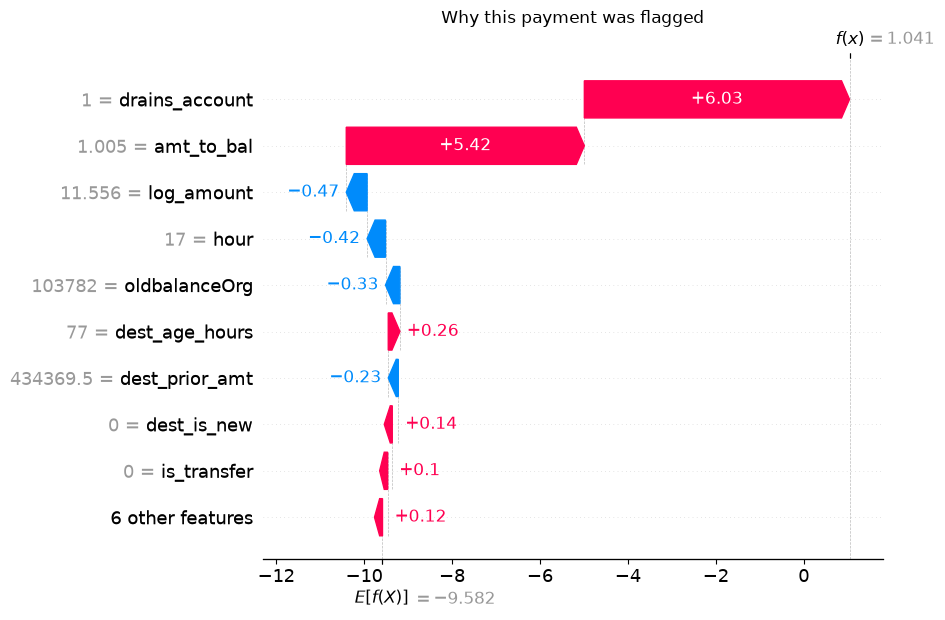

In [6]:
one = explainer(alerts[FEATURES].iloc[[0]])
if one.values.ndim == 3:
    one = one[:, :, 1]
shap.plots.waterfall(one[0], max_display=10, show=False)
plt.title("Why this payment was flagged")
plt.savefig("../reports/figures/shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
missed = te[(te["isFraud"] == 1) & (te["score"] < T)]
svm = explainer(missed[FEATURES])
vm = svm.values if svm.values.ndim == 2 else svm.values[:, :, 1]

pd.DataFrame(vm, columns=FEATURES, index=[f"missed_{i+1}" for i in range(len(missed))]).T.round(2)

,missed_1,missed_2,missed_3
is_transfer,0.35,0.25,0.74
log_amount,2.60,-0.05,2.58
oldbalanceOrg,1.56,0.82,1.47
amt_to_bal,1.93,-0.06,2.56
orig_zero_bal,0.00,0.00,0.00
drains_account,-0.17,-0.20,-0.18
is_round,-0.00,-0.00,-0.00
hour,-0.25,0.12,0.10
is_night,0.01,0.00,0.01
dest_prior_txn,0.04,0.04,0.04


In [8]:
def reason_text(f, v):
    if f == "is_transfer":    return "Payment type: " + ("transfer" if v == 1 else "cash-out")
    if f == "drains_account": return "Payment empties the account" if v == 1 else "Payment does not empty the account"
    if f == "dest_is_new":    return "Receiver is brand new" if v == 1 else "Receiver has been paid before"
    if f == "is_night":       return "Night-time payment (0–5am)" if v == 1 else "Daytime payment"
    if f == "is_round":       return "Round-number amount" if v == 1 else "Non-round amount"
    if f == "orig_zero_bal":  return "Sender balance is zero" if v == 1 else "Sender has a balance"
    return NICE[f]

X_alerts = alerts[FEATURES].to_numpy()
for k in range(3):
    alerts[f"reason_{k+1}"] = [reason_text(FEATURES[top[i, k]], X_alerts[i, top[i, k]])
                               for i in range(len(alerts))]

print(alerts["reason_1"].value_counts().head(5))
alerts[["type", "amount", "score", "isFraud", "reason_1", "reason_2", "reason_3"]].head(10)

reason_1
Payment as a share of balance    2561
Payment empties the account      1704
Round-number amount                 3
Name: count, dtype: int64


,type,amount,score,isFraud,reason_1,reason_2,reason_3
1159,CASH_OUT,104350.15,0.193548,0,Payment empties the account,Payment as a share of balance,How long the receiver has existed
2395,TRANSFER,2344540.14,1.000000,1,Payment as a share of balance,Payment empties the account,Sender's balance before payment
2396,CASH_OUT,2344540.14,1.000000,1,Payment as a share of balance,Payment empties the account,Payment size
3603,TRANSFER,434006.52,0.978261,1,Payment as a share of balance,Payment empties the account,How long the receiver has existed
3604,CASH_OUT,434006.52,0.583333,1,Payment empties the account,Payment as a share of balance,Payment type: cash-out
5146,CASH_OUT,34928.92,0.170455,0,Payment empties the account,Payment as a share of balance,How long the receiver has existed
5633,TRANSFER,73946.79,0.978261,1,Payment as a share of balance,Payment empties the account,Payment type: transfer
5634,CASH_OUT,73946.79,0.186945,1,Payment empties the account,Payment as a share of balance,Receiver's amount received in last 24h
5907,TRANSFER,503420.67,1.000000,1,Payment as a share of balance,Payment empties the account,How long the receiver has existed
5908,CASH_OUT,503420.67,0.707632,1,Payment empties the account,Payment as a share of balance,Payment type: cash-out


**Alert explanations:** alert reasons are dominated by "payment as a share of balance" and "payment empties the account", matching the global SHAP ranking. PaySim's two-step fraud is visible in the alerts (same amount as a TRANSFER then a CASH_OUT); the transfer leg typically scores near 1.0 while the cash-out leg scores lower (0.19–0.71), so the first step is easier to detect. False alarms are mainly legitimate cash-outs that empty the account, with borderline scores (~0.17–0.19). Reason text was made value-aware after spotting that binary features were labelled without their value (e.g. "payment is a transfer" shown for a cash-out).

**Missed frauds:** all three did not empty the account (drains_account SHAP −0.17 to −0.20), so they lacked the strongest positive signal the model relies on (average impact 1.53). Two still had strong risk signals (large amount, high share of balance, and in one case a brand-new receiver) but not enough to cross the threshold; the third looked like an ordinary payment. This confirms the model's main weakness: large partial transfers that don't empty the account.

In [9]:
rng = np.random.default_rng(0)
q = te["amt_to_bal"].rank(pct=True).to_numpy()
p_old = 0.15 + 0.30 * q
u = rng.random(len(te))
te["age_band"] = np.where(u < p_old, "65+", np.where(u < p_old + 0.35, "35-64", "18-34"))
te["alert"] = (te["score"] >= T).astype(int)

te["age_band"].value_counts(normalize=True).round(3)

age_band
18-34    0.35
35-64    0.35
65+      0.30
Name: proportion, dtype: float64

In [10]:
from fairlearn.metrics import MetricFrame, false_positive_rate, true_positive_rate, selection_rate, count

mf = MetricFrame(
    metrics={"payments": count,
             "alert_rate": selection_rate,
             "false_positive_rate": false_positive_rate,
             "fraud_caught_rate": true_positive_rate},
    y_true=te["isFraud"], y_pred=te["alert"], sensitive_features=te["age_band"])

display(mf.by_group)
print("Ratio of lowest to highest group (1.0 = perfectly equal):")
display(mf.ratio())

,payments,alert_rate,false_positive_rate,fraud_caught_rate
age_band,,,,
18-34,145771.0,0.013823,0.000855,0.998944
35-64,145677.0,0.010084,0.000603,1.000000
65+,124849.0,0.006280,0.000330,0.998656


Ratio of lowest to highest group (1.0 = perfectly equal):


payments               0.856474
alert_rate             0.454284
false_positive_rate    0.386439
fraud_caught_rate      0.998656
dtype: float64

In [11]:
from scipy.stats import chi2_contingency

legit = te[te["isFraud"] == 0]
tab = pd.crosstab(legit["age_band"], legit["alert"])
chi2, p, _, _ = chi2_contingency(tab)
print(tab)
print(f"\nChi-square p-value: {p:.4f}")

alert          0    1
age_band             
18-34     143754  123
35-64     144208   87
65+       124064   41

Chi-square p-value: 0.0000


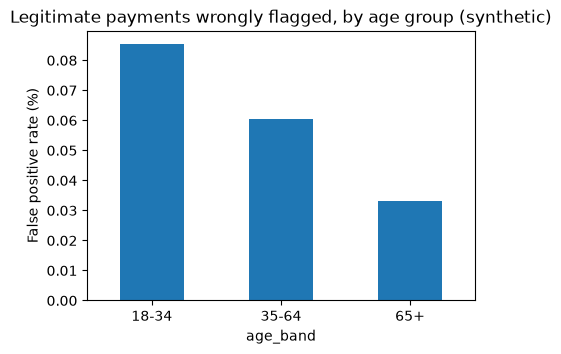

In [12]:
fpr = mf.by_group["false_positive_rate"] * 100
fpr.plot.bar(figsize=(5, 3.5), title="Legitimate payments wrongly flagged, by age group (synthetic)")
plt.ylabel("False positive rate (%)"); plt.xticks(rotation=0)
plt.savefig("../reports/figures/fairness_fpr.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
dash = te[["day", "type", "amount", "isFraud", "score", "age_band"]].copy()
dash = dash.join(alerts[["reason_1", "reason_2", "reason_3"]])
dash.insert(0, "alert_id", range(len(dash)))     # no account names stored
dash.to_parquet("../dashboard/data/test_scored.parquet")
print("Dashboard file size:", round(os.path.getsize("../dashboard/data/test_scored.parquet") / 1e6, 1), "MB")

Dashboard file size: 4.9 MB


## Explainability
- Every alert comes with its top 3 value-aware reasons (SHAP).
- Most important features overall: amount as a share of balance (mean |SHAP| 1.749) and whether the payment empties the account (1.532), together ~78% of total feature impact; then sender balance, receiver account age, payment size and hour.
- Main weakness revealed by SHAP: large partial transfers that do not empty the account.

## Fairness
- Tested with a **synthetic** age attribute linked to behaviour (PaySim has no demographics), to demonstrate proxy-discrimination checks.
- False positive rate by group: 18–34 0.086%, 35–64 0.060%, 65+ 0.033%; ratio 0.39 (below the 0.8 rule of thumb); chi-square p < 0.0001.
- Absolute rates are very small and fraud-catch rates are equal across groups. The disparity runs against younger customers because of how the proxy interacted with zero-balance accounts, showing that proxy effects must be measured, not assumed.

## Key takeaways
- **Global drivers (SHAP):** amount as a share of balance and whether the payment empties the account together account for ~78% of feature impact; sender balance, receiver account age, payment size and hour add context.
- **Per-alert explanations:** every alert has 3 value-aware, plain-English reasons, led by "payment as a share of balance" and "payment empties the account".
- **Missed frauds:** all three did not empty the account, so they lacked the model's strongest positive signal. This confirms the weakness on large partial transfers.
- **Fairness (synthetic age):** false positive rates of 0.086% / 0.060% / 0.033% (ratio 0.39, p < 0.0001), with equal fraud protection across groups. The disparity is small in absolute terms and runs counter to intuition, demonstrating that proxy effects must be measured.
- Model card written in reports/model_card.md.

## Key takeaways
- **Global drivers (SHAP):** amount as a share of balance and whether the payment empties the account together account for ~78% of feature impact; sender balance, receiver account age, payment size and hour add context.
- **Per-alert explanations:** every alert has 3 value-aware, plain-English reasons, led by "payment as a share of balance" and "payment empties the account".
- **Missed frauds:** all three did not empty the account, so they lacked the model's strongest positive signal. This confirms the weakness on large partial transfers.
- **Fairness (synthetic age):** false positive rates of 0.086% / 0.060% / 0.033% (ratio 0.39, p < 0.0001), with equal fraud protection across groups. The disparity is small in absolute terms and runs counter to intuition, demonstrating that proxy effects must be measured.
- **Dashboard data:** scored test set with alert reasons saved for the dashboard (4.9 MB, no account identifiers).
- Model card written in reports/model_card.md.